# 05 — Model 1: XAI + CMI on the band-power baseline (validating the mechanics)

**The point of this notebook.** Before we trust attribution methods and the CMI faithfulness metric on the
*opaque* CNNs/transformer, we validate them on a model whose reasoning we **already know**: the band-power
logistic baseline. Its coefficients tell us exactly which band drives each stage — most cleanly
**N3 (deep sleep) ← delta**. So we can ask the concrete question:

> **Do my attribution methods recover the band I know the model uses?** (Primary check: does N3's
> attribution land on **delta**?)

We apply **three** attribution methods and compute **CMI + concentration** for each, over the **5 named
bands** (delta / theta / alpha / sigma / beta), per class. This is the "start simple and interpretable to
understand the mechanics, then go complex" step — a known-answer dry run for the whole XAI/CMI pipeline,
and the first `model × method × CMI` row of the study.

**How attribution works here.** The model classifies a 5-dim vector of band powers, so we attribute over
those **5 bands**: the "signal" is the band-feature vector and the region grid has 5 regions (one per
band). Each region's attribution is therefore one band's importance — directly comparable to the model's
own per-band coefficients.

> **Run order:** run the setup cells (already have outputs), then the three **▶ RUN XAI** cells (one per
> method), then their plot cells, then the comparison cell. Each ▶ RUN XAI cell is the compute step.

In [1]:
import sys, json
from pathlib import Path
# Locate repo root robustly: walk up to the dir containing sleep_edf/ (depth-independent).
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "sleep_edf").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sleep_edf.loader import load_sleep_edf
from sleep_edf.bandpower import band_power_features, BAND_NAMES
from sleep_edf.xai_bandpower import (band_predict_proba, method_attributions_and_cmi,
                                     plot_band_attribution)
from harness.xai.regions import build_region_grid

CLASS_NAMES  = ["W", "N1", "N2", "N3", "REM"]
MODEL_SEED   = 0            # logreg is convex -> all 5 seeds are ~identical; use seed 0
N_PER_CLASS  = 100         # test epochs sampled PER class for attribution/CMI (raise for tighter estimates)
SAMPLE_SEED  = 42

OUT_DIR = PROJECT_ROOT / "sleep_edf" / "results" / "metrics"
FIG_DIR = PROJECT_ROOT / "sleep_edf" / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=3, suppress=True)
print("bands:", BAND_NAMES)

bands: ['delta', 'theta', 'alpha', 'sigma', 'beta']


## 0. Load the trained model + data (quick check)

We reproduce the exact band-power features and standardiser from notebook 04b (deterministic), then load
the **trained coefficients** from `model1_bandpower_seed0.json`. A quick predict check confirms the
reconstructed model matches the saved test accuracy — i.e. we're attributing the *real* trained model.

In [2]:
X_train, y_train = load_sleep_edf("train")     # 20K subsample (logs it)
X_test,  y_test  = load_sleep_edf("test")      # full 40,145

F_train = band_power_features(X_train)
F_test  = band_power_features(X_test)
scaler  = StandardScaler().fit(F_train)        # identical to 04b (deterministic)
Fte     = scaler.transform(F_test).astype(np.float32)

d = json.load(open(OUT_DIR / f"model1_bandpower_seed{MODEL_SEED}.json"))
coef, intercept = np.array(d["coef"]), np.array(d["intercept"])     # (5 classes, 5 bands), (5,)
pp = band_predict_proba(coef, intercept)
acc = float((pp(Fte).argmax(1) == y_test).mean())
print(f"loaded model1_bandpower_seed{MODEL_SEED}: coef {coef.shape} | "
      f"reconstructed test acc {acc:.4f} vs saved {d['accuracy']:.4f}  (match: {abs(acc-d['accuracy'])<1e-6})")

# region grid over the 5 bands (one region per band)
grid = build_region_grid(5, 20.0)
assert grid.n_regions == 5
print("band grid: n_regions =", grid.n_regions, "(delta/theta/alpha/sigma/beta)")

# balanced sample of standardised band vectors for attribution + CMI
rng = np.random.RandomState(SAMPLE_SEED)
sub_idx = np.concatenate([
    rng.choice(np.where(y_test == c)[0], size=min(N_PER_CLASS, int((y_test == c).sum())), replace=False)
    for c in range(len(CLASS_NAMES))])
Fsub, ysub = Fte[sub_idx], y_test[sub_idx]
print(f"attribution sample: {len(Fsub)} epochs ({N_PER_CLASS}/class) — used by all 3 methods")

[sleep_edf] training load: 20,000-epoch stratified subsample (seed 42)


loaded model1_bandpower_seed0: coef (5, 5) | reconstructed test acc 0.6454 vs saved 0.6454  (match: True)
band grid: n_regions = 5 (delta/theta/alpha/sigma/beta)
attribution sample: 500 epochs (100/class) — used by all 3 methods


## 1. The ground truth to test (from the model's own coefficients)

The model is linear, so it *tells us* what it uses — its coefficients per stage × band. **Importance is
about the MAGNITUDE of reliance, not sign**, so the band the model "uses most" for a stage is the one with
the largest **|coefficient|** (positive *or* negative). We hold the attribution methods against that.

- **PRIMARY — N3 is defined largely by (low) BETA.** The model's N3 row is **delta +1.44 (positive)** and
  **beta −9.80 (by far the largest magnitude, negative)**. So the band the model relies on MOST for N3 is
  **beta**: deep sleep has almost no fast (beta) activity and the model keys on that *absence* (large
  negative weight), with delta (slow waves) the positive secondary. A trustworthy attribution method,
  applied to N3, should therefore flag **beta** as most important (delta second). This is the clean check.
- **Secondary / muddier tendencies:** Wake/REM lean on the faster bands (beta/alpha/theta); N2 involves
  sigma (spindles)/theta; **N1 barely learned** (scarcest/weakest — caveat in the verdict). Looser, not
  hard requirements.

> **Interpretation note (subtlety, for the record).** N3's ground truth is **beta (strongly negative) +
> delta (positive)**. The model identifies N3 largely by **LOW beta**, so beta carries the biggest weight
> *in magnitude*. Attribution measures **how much the prediction relies on a band — magnitude, not sign** —
> so a correct method flags **beta** as N3's most-important band even though its coefficient is negative.
> The check therefore compares each method's top band against the model's **top-|coef|** band, NOT the top
> *positive* coefficient. Reporting "beta" for N3 is a **correct recovery**, not a failure — an
> interpretation lesson, not a bug in the XAI.

The next cell prints the coefficients with the **top-|coef|** band per stage.

In [3]:
print("model coefficients (stage x band)  [+ = toward stage; importance = |coef|]:")
print(f"{'stage':<6}" + "".join(f"{b:>9}" for b in BAND_NAMES) + "   top-|coef|")
for c, cn in enumerate(CLASS_NAMES):
    print(f"{cn:<6}" + "".join(f"{coef[c,j]:>9.2f}" for j in range(5))
          + f"   {BAND_NAMES[int(np.argmax(np.abs(coef[c])))]}")
print(f"\nPRIMARY ground truth (by MAGNITUDE) -> N3 top-|coef| band: "
      f"{BAND_NAMES[int(np.argmax(np.abs(coef[3])))]}  (beta {coef[3,4]:+.2f} strongest, delta {coef[3,0]:+.2f} positive)")

model coefficients (stage x band)  [+ = toward stage; importance = |coef|]:
stage     delta    theta    alpha    sigma     beta   top-|coef|
W         -0.16    -0.16     0.02    -1.52     4.52   beta
N1        -0.58     0.29     0.06    -0.30     3.24   beta
N2         0.13     0.38    -0.22     1.67    -0.93   sigma
N3         1.44    -1.55     0.42     0.84    -9.80   beta
REM       -0.84     1.04    -0.27    -0.68     2.97   beta

PRIMARY ground truth (by MAGNITUDE) -> N3 top-|coef| band: beta  (beta -9.80 strongest, delta +1.44 positive)


## 2. Section 1 — FeatureAblation (the validation control)

FeatureAblation hides one band at a time and measures the probability drop — the most direct "how much
does the model rely on this band." It is the **control**: it should land near the ground truth almost by
construction, confirming the pipeline is wired correctly.

**Order in this section (new):** compute → **attribution table** → **attribution heatmap (N3 highlighted)**
→ **ground-truth check** → **CMI**. Run the ▶ RUN XAI cell, then the display cells below it.

In [4]:
# ▶▶▶ RUN XAI (FeatureAblation) — computes per-band attribution + CMI for all sampled epochs ◀◀◀
res_fa = method_attributions_and_cmi("feature_ablation", Fsub, ysub, grid, coef, intercept,
                                     n_classes=len(CLASS_NAMES), pm="zero")
print("FeatureAblation: computed attribution over", len(Fsub), "epochs.",
      "Attribution shown next; CMI comes after the ground-truth check.")

FeatureAblation: computed attribution over 500 epochs. Attribution shown next; CMI comes after the ground-truth check.


In [5]:
# Attribution TABLE (rows = stage, cols = band) — which band FeatureAblation flagged, per stage.
A = np.array(res_fa["per_class_attr"])                     # (5 stages, 5 bands) — already computed above
print("FeatureAblation attribution (mean importance per stage x band):")
print(f"{'stage':<6}" + "".join(f"{b:>9}" for b in BAND_NAMES) + "   top band")
for c, cn in enumerate(CLASS_NAMES):
    print(f"{cn:<6}" + "".join(f"{A[c, j]:>9.3f}" for j in range(5))
          + f"   {BAND_NAMES[int(np.nanargmax(A[c]))]}")

FeatureAblation attribution (mean importance per stage x band):
stage     delta    theta    alpha    sigma     beta   top band
W        -0.026    0.036   -0.005    0.171   -0.071   sigma
N1        0.011   -0.010    0.010    0.022   -0.005   sigma
N2        0.023   -0.000    0.010   -0.017    0.336   beta
N3        0.315    0.221   -0.068    0.053    0.483   beta
REM       0.020    0.124   -0.011    0.044    0.001   theta


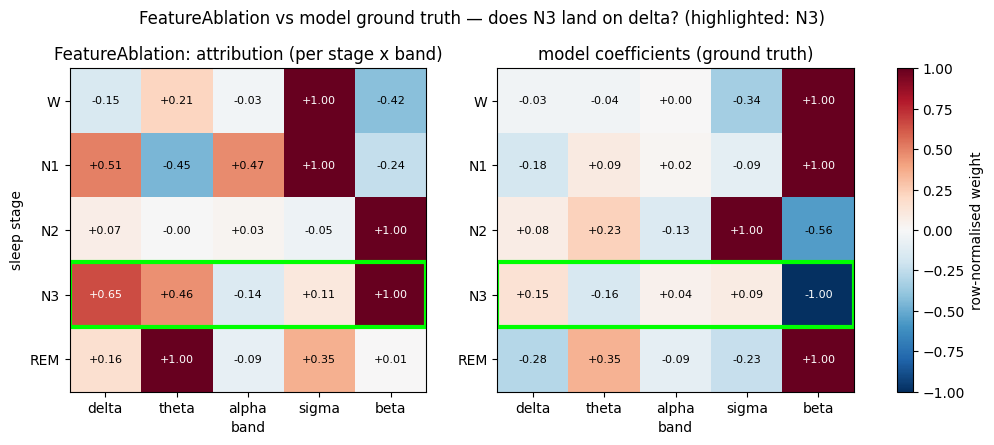

PRIMARY CHECK (N3) — attribution top band = beta | model top-|coef| band = beta (beta -9.80, delta +1.44)
  -> RECOVERED
per-class  (attribution top | model top-|coef| | match):
  W    sigma  beta   differ
  N1   sigma  beta   differ
  N2   beta   sigma  differ
  N3   beta   beta   match
  REM  theta  beta   differ
saved: sleep_edf_05_attr_feature_ablation.png


In [6]:
# Attribution HEATMAP (N3 row highlighted) vs the model coefficients (ground truth).
fig = plot_band_attribution(res_fa["per_class_attr"], coef, BAND_NAMES, CLASS_NAMES,
                            "FeatureAblation", FIG_DIR / "sleep_edf_05_attr_feature_ablation.png",
                            highlight_row=CLASS_NAMES.index("N3"))
plt.show()
# Ground truth = band the model weights most in ABSOLUTE terms (importance = magnitude of reliance,
# not sign); the attribution's most-important band is likewise taken by magnitude.
A = np.abs(np.array(res_fa["per_class_attr"])); Cf = np.abs(np.array(coef))
i3 = CLASS_NAMES.index("N3")
attr_top = BAND_NAMES[int(np.nanargmax(A[i3]))]
coef_top = BAND_NAMES[int(np.argmax(Cf[i3]))]
print(f"PRIMARY CHECK (N3) — attribution top band = {attr_top} | model top-|coef| band = {coef_top} "
      f"(beta {coef[3,4]:+.2f}, delta {coef[3,0]:+.2f})")
print("  ->", "RECOVERED" if attr_top == coef_top else f"NOT recovered (attr {attr_top} vs model {coef_top})")
print("per-class  (attribution top | model top-|coef| | match):")
for k, cn in enumerate(CLASS_NAMES):
    at = BAND_NAMES[int(np.nanargmax(A[k]))]; ct = BAND_NAMES[int(np.argmax(Cf[k]))]
    print(f"  {cn:<4} {at:<6} {ct:<6} {'match' if at == ct else 'differ'}")
print("saved:", (FIG_DIR / "sleep_edf_05_attr_feature_ablation.png").name)

### Ground-truth check — FeatureAblation (before any faithfulness number)

**Does N3's attribution land on the band the model relies on most?** By **magnitude** that band is **beta**
(N3 = beta −9.80, delta +1.44). Read the highlighted **N3 row** and the printed `PRIMARY CHECK`: it is
**recovered** iff FeatureAblation's most-important band for N3 (by magnitude) is **beta** — the model's top-|coef|
band (delta a positive second). As the control, FeatureAblation should recover this **cleanly**. State it plainly — recovered / didn't recover — before the CMI.

In [7]:
# Faithfulness of the attribution just shown (FeatureAblation).
print("FeatureAblation faithfulness:")
print(f"  CMI = {res_fa['cmi']['CMI']:.4f}   (higher = the bands this attribution flagged really do drive the model)")
print(f"  PES = {res_fa['cmi']['PES']:.4f}   |   concentration = {res_fa['concentration']:.4f}")

FeatureAblation faithfulness:
  CMI = 0.7182   (higher = the bands this attribution flagged really do drive the model)
  PES = 1.0000   |   concentration = 0.3376


## 3. Section 2 — KernelSHAP (the primary model-agnostic method, the ladder through-line)

KernelSHAP estimates each band's Shapley value — its fair contribution averaged over coalitions of the
other bands. It is the **primary** black-box method carried across the whole ladder (it works the same on
the CNNs/transformer, where there are no coefficients to peek at). Here we can check its answer against the
known ground truth.

**Order:** compute → attribution table → heatmap (N3 highlighted) → ground-truth check → CMI.

In [8]:
# ▶▶▶ RUN XAI (KernelSHAP) — computes per-band attribution + CMI for all sampled epochs ◀◀◀
res_ks = method_attributions_and_cmi("kernel_shap", Fsub, ysub, grid, coef, intercept,
                                     n_classes=len(CLASS_NAMES), pm="zero")
print("KernelSHAP: computed attribution over", len(Fsub), "epochs.",
      "Attribution shown next; CMI comes after the ground-truth check.")

KernelSHAP: computed attribution over 500 epochs. Attribution shown next; CMI comes after the ground-truth check.


In [9]:
# Attribution TABLE (rows = stage, cols = band) — which band KernelSHAP flagged, per stage.
A = np.array(res_ks["per_class_attr"])                     # (5 stages, 5 bands) — already computed above
print("KernelSHAP attribution (mean importance per stage x band):")
print(f"{'stage':<6}" + "".join(f"{b:>9}" for b in BAND_NAMES) + "   top band")
for c, cn in enumerate(CLASS_NAMES):
    print(f"{cn:<6}" + "".join(f"{A[c, j]:>9.3f}" for j in range(5))
          + f"   {BAND_NAMES[int(np.nanargmax(A[c]))]}")

KernelSHAP attribution (mean importance per stage x band):
stage     delta    theta    alpha    sigma     beta   top band
W        -0.017    0.038   -0.006    0.157   -0.056   sigma
N1        0.009   -0.015    0.011   -0.007   -0.032   alpha
N2        0.036   -0.002    0.001    0.036    0.397   beta
N3        0.146    0.101   -0.033    0.000    0.269   beta
REM       0.019    0.132   -0.005    0.005   -0.034   theta


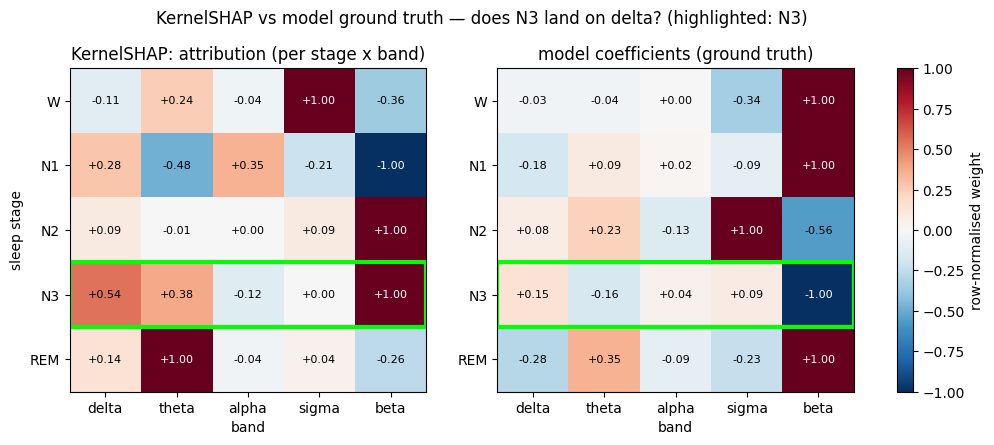

PRIMARY CHECK (N3) — attribution top band = beta | model top-|coef| band = beta (beta -9.80, delta +1.44)
  -> RECOVERED
per-class  (attribution top | model top-|coef| | match):
  W    sigma  beta   differ
  N1   beta   beta   match
  N2   beta   sigma  differ
  N3   beta   beta   match
  REM  theta  beta   differ
saved: sleep_edf_05_attr_kernel_shap.png


In [10]:
# Attribution HEATMAP (N3 row highlighted) vs the model coefficients (ground truth).
fig = plot_band_attribution(res_ks["per_class_attr"], coef, BAND_NAMES, CLASS_NAMES,
                            "KernelSHAP", FIG_DIR / "sleep_edf_05_attr_kernel_shap.png",
                            highlight_row=CLASS_NAMES.index("N3"))
plt.show()
# Ground truth = band the model weights most in ABSOLUTE terms (importance = magnitude of reliance,
# not sign); the attribution's most-important band is likewise taken by magnitude.
A = np.abs(np.array(res_ks["per_class_attr"])); Cf = np.abs(np.array(coef))
i3 = CLASS_NAMES.index("N3")
attr_top = BAND_NAMES[int(np.nanargmax(A[i3]))]
coef_top = BAND_NAMES[int(np.argmax(Cf[i3]))]
print(f"PRIMARY CHECK (N3) — attribution top band = {attr_top} | model top-|coef| band = {coef_top} "
      f"(beta {coef[3,4]:+.2f}, delta {coef[3,0]:+.2f})")
print("  ->", "RECOVERED" if attr_top == coef_top else f"NOT recovered (attr {attr_top} vs model {coef_top})")
print("per-class  (attribution top | model top-|coef| | match):")
for k, cn in enumerate(CLASS_NAMES):
    at = BAND_NAMES[int(np.nanargmax(A[k]))]; ct = BAND_NAMES[int(np.argmax(Cf[k]))]
    print(f"  {cn:<4} {at:<6} {ct:<6} {'match' if at == ct else 'differ'}")
print("saved:", (FIG_DIR / "sleep_edf_05_attr_kernel_shap.png").name)

### Ground-truth check — KernelSHAP (before any faithfulness number)

**Does N3's attribution land on the band the model relies on most?** By **magnitude** that band is **beta**
(N3 = beta −9.80, delta +1.44). Read the highlighted **N3 row** and the printed `PRIMARY CHECK`: it is
**recovered** iff KernelSHAP's most-important band for N3 (by magnitude) is **beta** — the model's top-|coef|
band (delta a positive second). This is the important one: KernelSHAP is the method we carry to the opaque models. State it plainly — recovered / didn't recover — before the CMI.

In [11]:
# Faithfulness of the attribution just shown (KernelSHAP).
print("KernelSHAP faithfulness:")
print(f"  CMI = {res_ks['cmi']['CMI']:.4f}   (higher = the bands this attribution flagged really do drive the model)")
print(f"  PES = {res_ks['cmi']['PES']:.4f}   |   concentration = {res_ks['concentration']:.4f}")

KernelSHAP faithfulness:
  CMI = 0.7180   (higher = the bands this attribution flagged really do drive the model)
  PES = 1.0000   |   concentration = 0.3522


## 4. Section 3 — Integrated Gradients (included for consistency; near-trivial here)

Integrated Gradients integrates the model's gradient along a path from a baseline to the input.

> **Flag:** for a **linear** model IG is **near-trivial** — it approximately reduces to *feature × weight*,
> so it mostly re-reads the coefficients rather than adding independent insight. Included for **method
> consistency across the ladder** (IG becomes informative on the non-linear CNNs/transformer). Treat a good
> IG↔ground-truth match here as a sanity check, not a discovery.

**Order:** compute → attribution table → heatmap (N3 highlighted) → ground-truth check → CMI.

In [12]:
# ▶▶▶ RUN XAI (IntegratedGradients) — computes per-band attribution + CMI for all sampled epochs ◀◀◀
res_ig = method_attributions_and_cmi("integrated_gradients", Fsub, ysub, grid, coef, intercept,
                                     n_classes=len(CLASS_NAMES), pm="zero")
print("IntegratedGradients: computed attribution over", len(Fsub), "epochs.",
      "Attribution shown next; CMI comes after the ground-truth check.")

IntegratedGradients: computed attribution over 500 epochs. Attribution shown next; CMI comes after the ground-truth check.


In [13]:
# Attribution TABLE (rows = stage, cols = band) — which band IntegratedGradients flagged, per stage.
A = np.array(res_ig["per_class_attr"])                     # (5 stages, 5 bands) — already computed above
print("IntegratedGradients attribution (mean importance per stage x band):")
print(f"{'stage':<6}" + "".join(f"{b:>9}" for b in BAND_NAMES) + "   top band")
for c, cn in enumerate(CLASS_NAMES):
    print(f"{cn:<6}" + "".join(f"{A[c, j]:>9.3f}" for j in range(5))
          + f"   {BAND_NAMES[int(np.nanargmax(A[c]))]}")

IntegratedGradients attribution (mean importance per stage x band):
stage     delta    theta    alpha    sigma     beta   top band
W        -0.023    0.044   -0.009    0.201   -0.097   sigma
N1        0.012   -0.014    0.010    0.011   -0.054   delta
N2        0.051   -0.009    0.003    0.002    0.421   beta
N3        0.089    0.058   -0.018   -0.011    0.364   beta
REM       0.023    0.146   -0.009    0.007   -0.049   theta


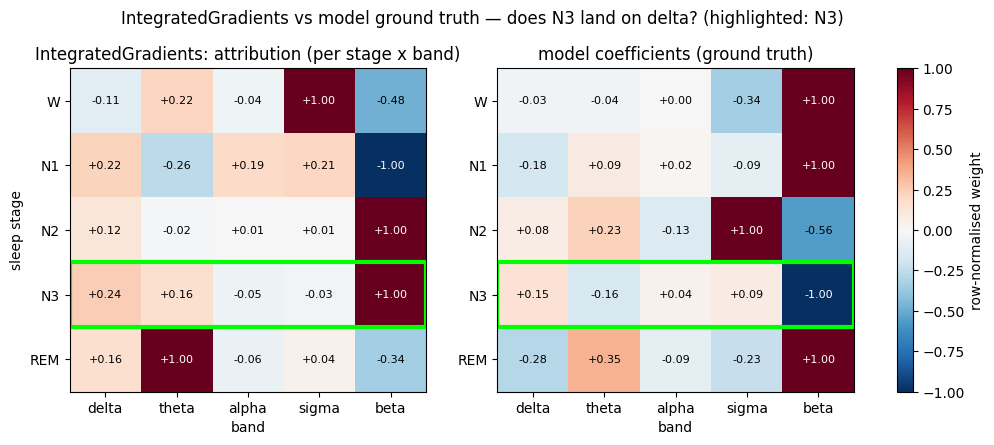

PRIMARY CHECK (N3) — attribution top band = beta | model top-|coef| band = beta (beta -9.80, delta +1.44)
  -> RECOVERED
per-class  (attribution top | model top-|coef| | match):
  W    sigma  beta   differ
  N1   beta   beta   match
  N2   beta   sigma  differ
  N3   beta   beta   match
  REM  theta  beta   differ
saved: sleep_edf_05_attr_integrated_gradients.png


In [14]:
# Attribution HEATMAP (N3 row highlighted) vs the model coefficients (ground truth).
fig = plot_band_attribution(res_ig["per_class_attr"], coef, BAND_NAMES, CLASS_NAMES,
                            "IntegratedGradients", FIG_DIR / "sleep_edf_05_attr_integrated_gradients.png",
                            highlight_row=CLASS_NAMES.index("N3"))
plt.show()
# Ground truth = band the model weights most in ABSOLUTE terms (importance = magnitude of reliance,
# not sign); the attribution's most-important band is likewise taken by magnitude.
A = np.abs(np.array(res_ig["per_class_attr"])); Cf = np.abs(np.array(coef))
i3 = CLASS_NAMES.index("N3")
attr_top = BAND_NAMES[int(np.nanargmax(A[i3]))]
coef_top = BAND_NAMES[int(np.argmax(Cf[i3]))]
print(f"PRIMARY CHECK (N3) — attribution top band = {attr_top} | model top-|coef| band = {coef_top} "
      f"(beta {coef[3,4]:+.2f}, delta {coef[3,0]:+.2f})")
print("  ->", "RECOVERED" if attr_top == coef_top else f"NOT recovered (attr {attr_top} vs model {coef_top})")
print("per-class  (attribution top | model top-|coef| | match):")
for k, cn in enumerate(CLASS_NAMES):
    at = BAND_NAMES[int(np.nanargmax(A[k]))]; ct = BAND_NAMES[int(np.argmax(Cf[k]))]
    print(f"  {cn:<4} {at:<6} {ct:<6} {'match' if at == ct else 'differ'}")
print("saved:", (FIG_DIR / "sleep_edf_05_attr_integrated_gradients.png").name)

### Ground-truth check — Integrated Gradients (before any faithfulness number)

**Does N3's attribution land on the band the model relies on most?** By **magnitude** that band is **beta**
(N3 = beta −9.80, delta +1.44). Read the highlighted **N3 row** and the printed `PRIMARY CHECK`: it is
**recovered** iff Integrated Gradients's most-important band for N3 (by magnitude) is **beta** — the model's top-|coef|
band (delta a positive second). For this linear model IG ≈ feature × weight, so it should track the coefficients. State it plainly — recovered / didn't recover — before the CMI.

In [15]:
# Faithfulness of the attribution just shown (IntegratedGradients).
print("IntegratedGradients faithfulness:")
print(f"  CMI = {res_ig['cmi']['CMI']:.4f}   (higher = the bands this attribution flagged really do drive the model)")
print(f"  PES = {res_ig['cmi']['PES']:.4f}   |   concentration = {res_ig['concentration']:.4f}")

IntegratedGradients faithfulness:
  CMI = 0.7118   (higher = the bands this attribution flagged really do drive the model)
  PES = 0.9960   |   concentration = 0.3594


## 5. Comparison — which method recovers N3 → delta, and the CMI row

Two combined views: (1) the three methods' **N3-row attributions side by side** against the model's own
N3 coefficients (the reference ground truth) — so you can see which method most cleanly recovers
**N3 → delta**; and (2) the three-method **CMI / PES / concentration** table (Model 1's `model × method ×
CMI` row). This is the first CMI computation, so it doubles as a sanity check that the CMI machinery
produces sensible numbers on a model whose reasoning is known and clean.

N3 row — importance per band (raw values), and the top band each flags:
source                    delta    theta    alpha    sigma     beta   top band
model coef (truth)         1.44    -1.55     0.42     0.84    -9.80   delta
FeatureAblation            0.31     0.22    -0.07     0.05     0.48   beta
KernelSHAP                 0.15     0.10    -0.03     0.00     0.27   beta
IntegratedGradients        0.09     0.06    -0.02    -0.01     0.36   beta


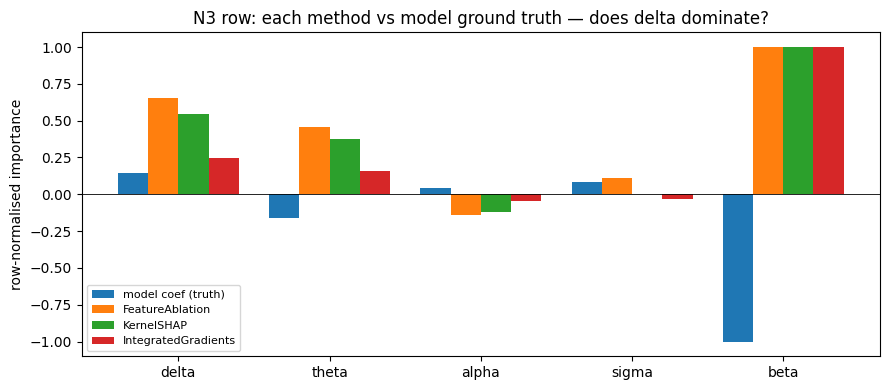

saved: sleep_edf_05_n3_comparison.png


In [16]:
# (1) N3-row attributions: each method vs the model coefficient (ground truth).
n3_rows = {"model coef (truth)": np.array(coef)[3],
           "FeatureAblation":     np.array(res_fa["per_class_attr"])[3],
           "KernelSHAP":          np.array(res_ks["per_class_attr"])[3],
           "IntegratedGradients": np.array(res_ig["per_class_attr"])[3]}
print("N3 row — importance per band (raw values), and the top band each flags:")
print(f"{'source':<22}" + "".join(f"{b:>9}" for b in BAND_NAMES) + "   top band")
for name, v in n3_rows.items():
    print(f"{name:<22}" + "".join(f"{v[j]:>9.2f}" for j in range(5))
          + f"   {BAND_NAMES[int(np.nanargmax(v))]}")

# grouped bar of row-normalised N3 importances (shape comparison; delta bar should dominate)
fig, ax = plt.subplots(figsize=(9, 4)); x = np.arange(len(BAND_NAMES)); w = 0.2
for k, (name, v) in enumerate(n3_rows.items()):
    v = np.array(v, float); vn = v / (np.nanmax(np.abs(v)) or 1.0)
    ax.bar(x + (k - 1.5) * w, vn, width=w, label=name)
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(x); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel("row-normalised importance"); ax.legend(fontsize=8)
ax.set_title("N3 row: each method vs model ground truth — does delta dominate?")
fig.tight_layout(); fig.savefig(FIG_DIR / "sleep_edf_05_n3_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved:", (FIG_DIR / "sleep_edf_05_n3_comparison.png").name)

method                     CMI     DDS     PES  concentration   N3->delta?
----------------------------------------------------------------------
FeatureAblation          0.718   0.560   1.000          0.338   NO (beta)
KernelSHAP               0.718   0.560   1.000          0.352   NO (beta)
IntegratedGradients      0.712   0.554   0.996          0.359   NO (beta)


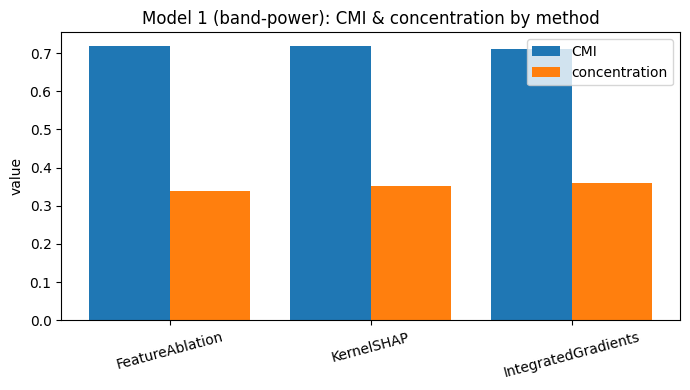

saved: sleep_edf_05_cmi_comparison.png


In [17]:
# (2) three-method CMI comparison (Model 1's model x method x CMI row).
results = {"FeatureAblation": res_fa, "KernelSHAP": res_ks, "IntegratedGradients": res_ig}
print(f"{'method':<22}{'CMI':>8}{'DDS':>8}{'PES':>8}{'concentration':>15}   N3->delta?")
print("-" * 70)
rows = []
for name, r in results.items():
    n3_band = BAND_NAMES[int(np.nanargmax(np.array(r["per_class_attr"])[3]))]
    rows.append((name, r["cmi"]["CMI"], r["cmi"]["DDS"], r["cmi"]["PES"], r["concentration"], n3_band))
    print(f"{name:<22}{r['cmi']['CMI']:>8.3f}{r['cmi']['DDS']:>8.3f}{r['cmi']['PES']:>8.3f}"
          f"{r['concentration']:>15.3f}   {'YES' if n3_band == 'delta' else 'NO (' + n3_band + ')'}")

fig, ax = plt.subplots(figsize=(7, 4)); names = [r[0] for r in rows]
ax.bar(np.arange(len(names)) - 0.2, [r[1] for r in rows], width=0.4, label="CMI")
ax.bar(np.arange(len(names)) + 0.2, [r[4] for r in rows], width=0.4, label="concentration")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=15); ax.set_ylabel("value")
ax.set_title("Model 1 (band-power): CMI & concentration by method"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "sleep_edf_05_cmi_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved:", (FIG_DIR / "sleep_edf_05_cmi_comparison.png").name)

## 6. Verdict (fill in after running)

The "do the mechanics work on a known-answer model" check, before trusting them on the opaque CNNs:

- **Did each method recover N3 → delta?** (the primary target — see the per-method N3 band and the
  comparison table's `N3->delta?` column). Which method recovered it **best/most cleanly**?
- **Do CMI / concentration look sane?** Non-degenerate, in range, and the control (FeatureAblation) at
  least as faithful as the others — evidence the CMI machinery produces sensible numbers.
- **N1 caveat:** N1 barely learned (scarcest, weakest stage), so its attribution/faithfulness is
  near-meaningless **for this model** — do not over-read N1 here; flagged and carried forward.

If N3→delta is recovered and the CMI numbers are sensible, the XAI+CMI pipeline is validated on a known
answer and can be trusted as we move up the ladder to the opaque models (where there are no coefficients
to check against).